# Progress showcase -- vascular tree reconstruction

The goal of this project: given a (often broken/fragmented) vessel segmentation mask, produce
a connected vascular tree **graph** -- not just a cleaned-up point cloud -- with plausible
radii and topology, that a downstream viewer/analysis tool can consume.

This notebook is a progress report, not a new method. It walks through the three approaches
actually tried, in the order they were tried, and for each one shows the same kind of evidence:
4 real cases, rendered in 3D, with a short explanation of what the method does and what its
output shows. Full technical detail for each stage lives in `lab_diary.md` and
`README_LABEL_CONNECTED.md` -- this notebook is the visual summary of that record, not a
replacement for it.

Three stages:

1. **Basic CCO** (`VascularTreeReconstruction`/`MultiTreeReconstruction`) -- the original
   approach: sparse k-NN connectivity + Kamiya/CCO physics-based radius optimisation. Still the
   simplest working baseline in this project.
2. **Heuristic-improved CCO** (historical -- the code for this stage has since been pruned, only
   its exported results survive) -- an attempt to fix specific weaknesses of stage 1
   (fabricated k-NN shortcut edges, non-physical roots, bifurcation math bugs). It improved
   per-tree quality but never solved the actual separation problem: it still bridges gaps
   aggressively, so a segmentation with real gaps between vessels comes back as one bridged
   blob more often than not.
3. **Label-connected** (`LabelConnectedMultiTreeReconstruction`, current, kept) -- the one
   that stuck. It trusts the segmentation's own connectivity first (no bridging at all) and
   only splits a component when there genuinely aren't enough natural ones, cutting at real
   branch points instead of an arbitrary geometric line.


## 0. Setup

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection

import importlib
import reconstruction
importlib.reload(reconstruction)
from reconstruction import (
    MultiTreeReconstruction,
    LabelConnectedMultiTreeReconstruction,
    load_thinning,
    estimate_point_radii_from_mask,
    adaptive_reconstruct_basic,
    adaptive_reconstruct_labelconnected,
)

assert hasattr(reconstruction, "LabelConnectedMultiTreeReconstruction"), \
    "stale reconstruction module loaded -- restart the kernel and run all"

ZENODO_DIR = Path("..") / "zenodo_skeletons" / "Task08_HepaticVessel" / "labelsTr"
TESTDATA = Path("test-data")

ZENODO_CASES = ["hepaticvessel_001", "hepaticvessel_002", "hepaticvessel_004",
                "hepaticvessel_005", "hepaticvessel_007", "hepaticvessel_008",
                "hepaticvessel_010", "hepaticvessel_011", "hepaticvessel_013",
                "hepaticvessel_016", "hepaticvessel_018"]

# Fixed seed -> reproducible "random" case selection (same 4 cases every re-run of
# this notebook), drawn from the same 11-case pool used throughout this project.
rng = np.random.default_rng(20260824)
RANDOM_CASES = list(rng.choice(ZENODO_CASES, size=4, replace=False))
print("Random cases for stages 1 and 3:", RANDOM_CASES)

# Stage 2 (heuristic-improved) only ever ran on these 4 -- its code is gone, only
# these exports survive, so they aren't a fresh random draw, just what's on disk.
HEURISTIC_CASES = ["hepaticvessel_001", "hepaticvessel_008", "hepaticvessel_010", "hepaticvessel_011"]


Random cases for stages 1 and 3: ['hepaticvessel_016', 'hepaticvessel_011', 'hepaticvessel_013', 'hepaticvessel_005']


## 1. Plotting helper

One function, reused for every stage below, so the three methods are shown with identical
rendering (colour = tree index, line width = vessel radius). Reads the exact viewer JSON
schema every stage in this project already exports to (`{"start","end","radius","Q"}` branch
list per tree file) -- so this works identically whether the trees came from a fresh run in
this notebook or from an old export left over from removed code.


In [2]:
def load_tree_branches(json_path):
    with open(json_path) as f:
        return json.load(f)


def plot_case(ax, tree_files, title):
    colors = plt.cm.tab10.colors
    total_branches = 0
    for tree_idx, path in enumerate(tree_files):
        if not Path(path).exists():
            continue
        branches = load_tree_branches(path)
        total_branches += len(branches)
        segments = [(b["start"], b["end"]) for b in branches]
        widths = [max(0.4, min(4.0, b["radius"])) for b in branches]
        lc = Line3DCollection(segments, colors=colors[tree_idx % 10], linewidths=widths)
        ax.add_collection3d(lc)

    # autoscale: Line3DCollection doesn't do this on its own
    all_pts = np.array([pt for path in tree_files if Path(path).exists()
                         for b in load_tree_branches(path) for pt in (b["start"], b["end"])])
    if len(all_pts):
        ax.set_xlim(all_pts[:, 0].min(), all_pts[:, 0].max())
        ax.set_ylim(all_pts[:, 1].min(), all_pts[:, 1].max())
        ax.set_zlim(all_pts[:, 2].min(), all_pts[:, 2].max())
    ax.set_title(f"{title}\n({total_branches} branches, {sum(1 for p in tree_files if Path(p).exists())} trees)",
                 fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])


def plot_stage(stage_title, cases, tree_files_fn):
    fig = plt.figure(figsize=(16, 4.5))
    fig.suptitle(stage_title, fontsize=13)
    for i, case in enumerate(cases):
        ax = fig.add_subplot(1, len(cases), i + 1, projection="3d")
        plot_case(ax, tree_files_fn(case), case)
    plt.tight_layout()
    plt.show()


## 2. Stage 1 -- Basic CCO

`MultiTreeReconstruction` over `VascularTreeReconstruction`: build a sparse k-nearest-neighbour
graph over the raw skeleton points, reduce it to a spanning tree, then optimise radii along
that tree using Kamiya/CCO physics (Murray's law: parent radius^gamma = sum of child
radius^gamma). It has no notion of the segmentation's own connectivity -- it purely reasons
about Euclidean proximity between points, iteratively peeling off one tree at a time until
`n_trees` are found or points run out.

Run live here on the 4 random cases (`n_trees=3`, defaults otherwise) and exported to
`test-data/showcase_basiccco_*` so they're also viewable afterwards.


In [3]:
basic_results = {}

for case in RANDOM_CASES:
    mask_path = ZENODO_DIR / f"{case}_mod.nii.gz"
    data = nib.load(str(mask_path)).get_fdata()
    vessel = (data == 1) if 1.0 in np.unique(data) else (data > 0)
    pts = load_thinning(vessel)

    t0 = time.time()
    rec = MultiTreeReconstruction(pts, n_trees=3)
    trees = rec.reconstruct_multiple_trees()
    elapsed = time.time() - t0

    prefix = str(TESTDATA / f"showcase_basiccco_{case}")
    rec.export_all_trees(prefix)

    basic_results[case] = {
        "n_points": len(pts),
        "trees_out": len(trees),
        "leftover": len(rec.remaining_points),
        "elapsed_s": round(elapsed, 2),
        "files": [f"{prefix}_tree{i+1}.json" for i in range(len(trees))],
    }
    print(f"{case}: {len(pts)} points -> {len(trees)} trees, "
          f"{len(rec.remaining_points)} leftover, {elapsed:.1f}s")


Starting multi-tree reconstruction from 2548 points
Target: 3 trees

ITERATION 1: 2548 points remaining

Using root candidate method: highest_z
Step 1: Building sparse graph (k=5)...
Step 2: Finding connected components...
  Found 4 components
  Largest component: 2524 nodes
Step 3: Extracting subgraph with 2524 points...
Step 4: Optimizing tree (k=10)...
Building graph from skeleton points...
Graph built: 2524 nodes, 2523 edges
Found 5 candidates from superior endpoints
Found 5 root candidates

Evaluating 5 root candidates...

Candidate 1/5: node 1202
  Terminals: 150, Total nodes: 2524
  Optimizing 145 bifurcations...
  Metrics: volume=21.33, murray_error=0.0000, radius_violations=0

Candidate 2/5: node 277
  Terminals: 150, Total nodes: 2524
  Optimizing 145 bifurcations...
  Metrics: volume=75.38, murray_error=0.0000, radius_violations=0

Candidate 3/5: node 1491
  Terminals: 150, Total nodes: 2524
  Optimizing 145 bifurcations...
  Metrics: volume=81.22, murray_error=0.0000, radiu

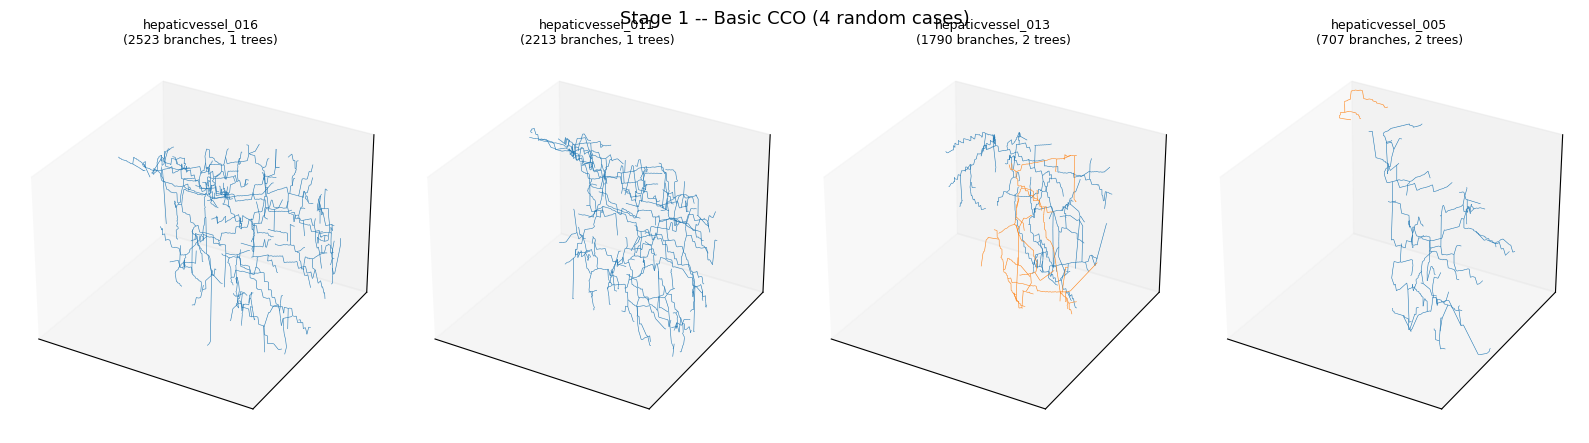

In [4]:
plot_stage("Stage 1 -- Basic CCO (4 random cases)", RANDOM_CASES,
           lambda case: basic_results[case]["files"])


**What to look for:** basic CCO produces plausible-looking individual trees, but "3 trees" here
usually means 3 arbitrary chunks of Euclidean-nearby points, not 3 anatomically distinct
vessels -- it has no way to tell the difference. Leftover-point counts above (points not
assigned to any of the 3 trees) show the other failure mode: when nearby points don't form a
clean enough k-NN neighbourhood, they're simply dropped rather than reconstructed.


## 3. Stage 2 -- Heuristic-improved CCO (historical)

Built on top of stage 1 to fix specific, concretely identified problems: fabricated "shortcut"
edges from k-NN connecting points across separate vessels, roots picked without using local
vessel radius, and two silent bugs in the bifurcation-radius optimiser that were cancelling
most of its own effect (documented in `lab_diary.md` sections 4.1-4.5).

It measurably improved per-tree quality, but not the thing this project actually needs: it
still bridges gaps between components aggressively (`ImprovedVascularTreeReconstruction`'s
default connectivity strategy), so a segmentation with genuine gaps between separate vessels
tends to come back bridged into one mass rather than kept apart. That's why it was eventually
dropped in favour of stage 3 below -- "prune methods that don't provide real separation" is
exactly this failure.

Its investigation notebook (`HeuristicImprovements.ipynb`) was removed once its finding was
folded into `lab_diary.md` and superseded by stage 3, so it can't be re-run here -- these are
the 4 cases it was ever validated on, loaded from its surviving exports
(`test-data/hepaticvessel_0{01,08,10,11}_heuristics_tree*.json`).


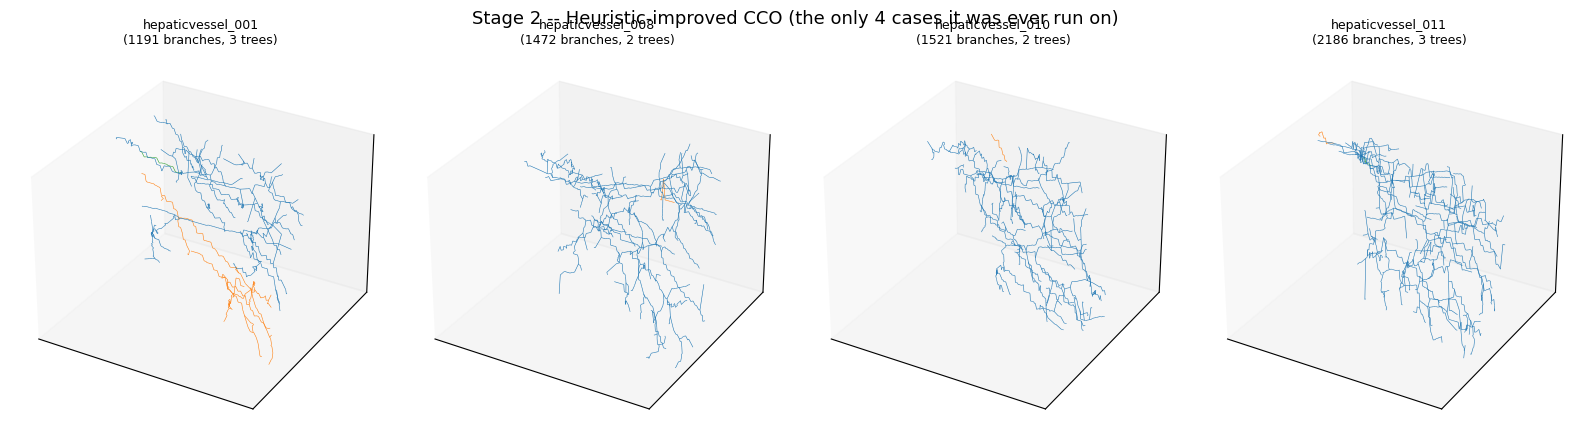

In [5]:
def heuristic_files(case):
    return sorted(TESTDATA.glob(f"{case}_heuristics_tree*.json"))

plot_stage("Stage 2 -- Heuristic-improved CCO (the only 4 cases it was ever run on)",
           HEURISTIC_CASES, heuristic_files)


**What to look for:** compare tree/branch counts here against stage 1 on the same underlying
datasets (`hepaticvessel_001` appears in both stage 1's random draw only by chance -- check the
printed case names above). The individual trees are visibly cleaner (fewer stray shortcut
edges), but the number of *separate* trees found is still governed by how aggressively gaps get
bridged, not by where the segmentation actually has real gaps -- the problem stage 3 targets
directly.


## 4. Stage 3 -- Label-connected (current method)

`LabelConnectedMultiTreeReconstruction`: stage 1 builds a graph from real voxel adjacency only
(26-neighbourhood) with **zero** bridging -- if the segmentation doesn't connect two points,
neither does this method. Each natural connected component becomes a tree candidate. Only if
there still aren't enough components to reach `n_trees` does it split the dominant one, and
even then it cuts at the component's own real branch points (nodes of degree >= 3) rather than
an arbitrary geometric line.

Already exported for every dataset in this project by `LabelConnectedExportAll.ipynb`
(`n_trees=3` for every Zenodo case) -- reused here rather than recomputed, so this is exactly
the production output, not a notebook-local approximation. Same 4 random cases as stage 1, so
this section is directly comparable to it.


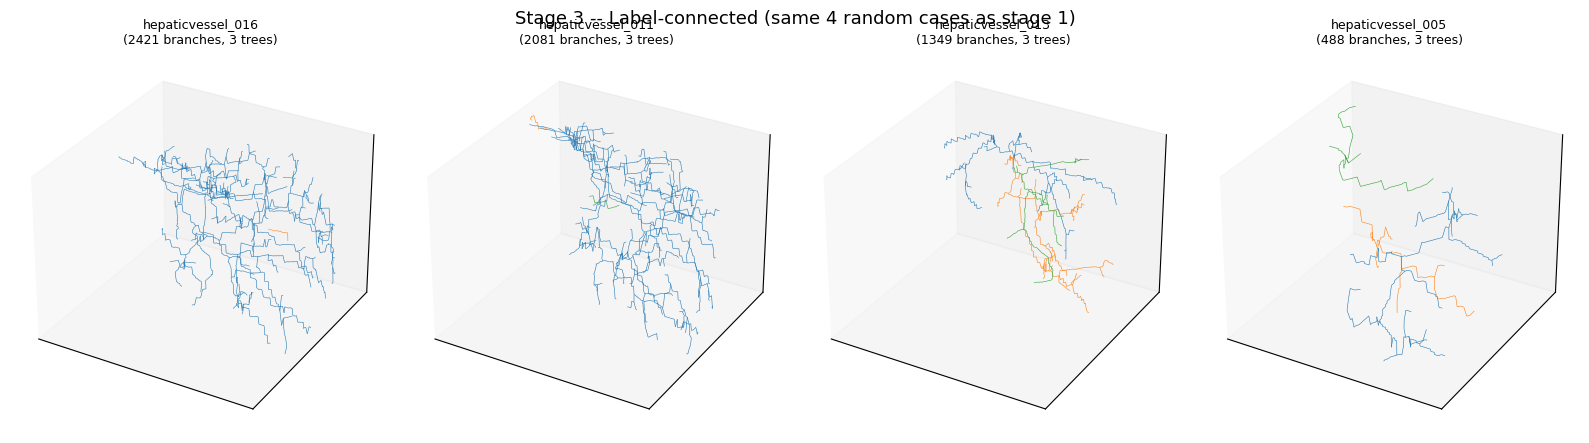

In [6]:
def labelconnected_files(case):
    return sorted(TESTDATA.glob(f"{case}_labelconnected_tree*.json"))

plot_stage("Stage 3 -- Label-connected (same 4 random cases as stage 1)", RANDOM_CASES,
           labelconnected_files)


**What to look for:** tree count and shape here reflect the segmentation's own real
connectivity -- e.g. one large dominant tree plus 1-2 much smaller genuine fragments is common
and expected (see `README_LABEL_CONNECTED.md` sections 5/8 for per-dataset numbers), not a sign
of failure the way a lone bridged blob would be in stage 1/2. No points are silently dropped:
every point either lands in a component/split or the run says so explicitly.


## 5. Direct comparison -- stage 1 vs. stage 3 on identical input

Same 4 datasets, same `n_trees=3`, only the method differs. This is the clearest evidence for
why stage 3 replaced stage 1/2 as the method actually used going forward.


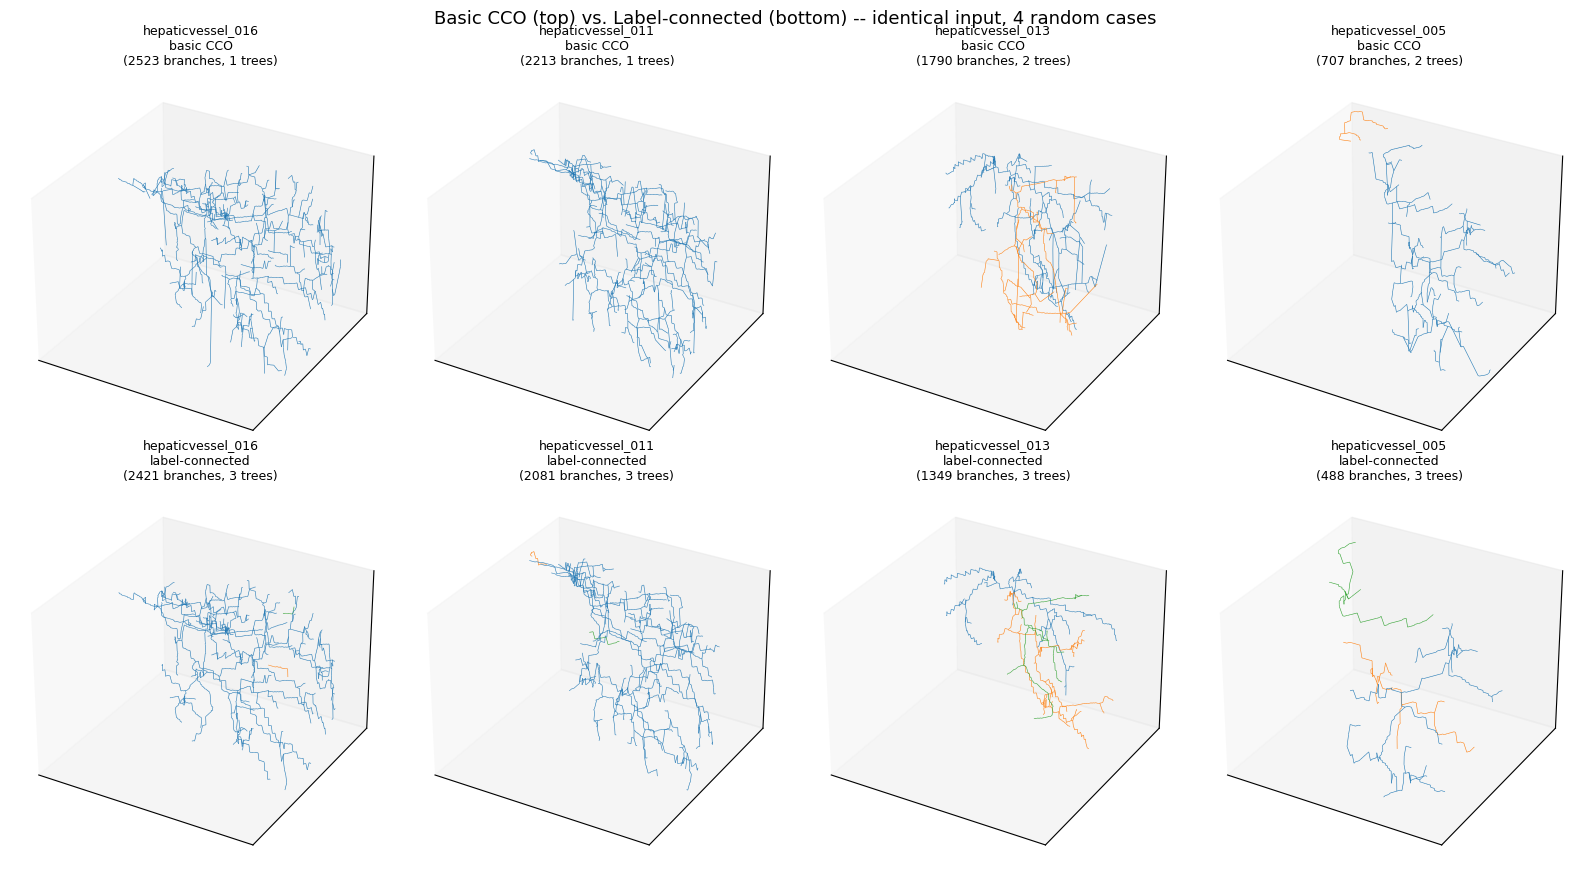

In [7]:
fig = plt.figure(figsize=(16, 9))
fig.suptitle("Basic CCO (top) vs. Label-connected (bottom) -- identical input, 4 random cases", fontsize=13)
for i, case in enumerate(RANDOM_CASES):
    ax_top = fig.add_subplot(2, len(RANDOM_CASES), i + 1, projection="3d")
    plot_case(ax_top, basic_results[case]["files"], f"{case}\nbasic CCO")

    ax_bot = fig.add_subplot(2, len(RANDOM_CASES), len(RANDOM_CASES) + i + 1, projection="3d")
    plot_case(ax_bot, labelconnected_files(case), f"{case}\nlabel-connected")
plt.tight_layout()
plt.show()


## 6. Closing the gap -- adaptive parameter search

Stage 1 fell short of `n_trees=3` on all 4 random cases (section 2). That shortfall isn't a
hard limit of the method -- both `MultiTreeReconstruction` and
`LabelConnectedMultiTreeReconstruction` expose parameters that control how readily they split
points into separate trees, and their defaults are just one fixed point on that dial, not
necessarily the best one for every dataset.

`adaptive_reconstruct_basic` / `adaptive_reconstruct_labelconnected` (`reconstruction.py`) retry
each method with progressively relaxed parameters, logging every attempt, and keep the
best-scoring one instead of silently accepting the first (default) result:

- **Basic CCO ladder**: default params -> halve `min_tree_size` toward a floor (stop treating
  small-but-real fragments as noise) -> lower `k_neighbors_initial` toward a floor (a sparser
  initial graph splits more readily).
- **Label-connected ladder**: `split_method="bifurcation"` (default, anatomically-grounded, may
  deliberately return fewer than `n_trees`) -> `split_method="voronoi"` (always able to divide
  further, geometric rather than anatomical) -> halve `min_tree_size` toward a floor.

Neither ladder invents a split that isn't backed by one of these real, already-existing knobs --
if every rung is exhausted and the target still isn't reached, the best attempt found is kept
and reported honestly as still short, not padded out artificially.


In [ ]:
adaptive_basic_results = {}
adaptive_basic_logs = {}

for case in RANDOM_CASES:
    mask_path = ZENODO_DIR / f"{case}_mod.nii.gz"
    data = nib.load(str(mask_path)).get_fdata()
    vessel = (data == 1) if 1.0 in np.unique(data) else (data > 0)
    pts = load_thinning(vessel)

    print(f"=== {case} ===")
    rec, log = adaptive_reconstruct_basic(pts, n_trees=3)
    adaptive_basic_logs[case] = log

    prefix = str(TESTDATA / f"showcase_basiccco_adaptive_{case}")
    rec.export_all_trees(prefix)
    adaptive_basic_results[case] = {
        "files": [f"{prefix}_tree{i+1}.json" for i in range(len(rec.trees))],
        "before": basic_results[case]["trees_out"],
        "after": len(rec.trees),
    }
    print()

print("before -> after (trees found / 3 requested):")
for case, r in adaptive_basic_results.items():
    print(f"  {case}: {r['before']} -> {r['after']}")


In [ ]:
plot_stage("Stage 1, adaptive -- Basic CCO after parameter relaxation (same 4 cases)",
           RANDOM_CASES, lambda case: adaptive_basic_results[case]["files"])


**What to look for:** compare tree/leftover counts here against section 2's plain-default run on
the identical 4 cases. Where this recovers `3/3` trees, it's because the real vessel structure
was there all along -- the default `min_tree_size=50`/`k_neighbors_initial=5` combination was
just too conservative to find it, not because the underlying method is incapable. Where it still
falls short after the full ladder, that's a more honest signal that the point cloud itself
doesn't cleanly separate into 3 pieces for this method, worth comparing against stage 3's natural
component count for the same case.


## 7. Same search, label-connected

For comparison: label-connected already reaches `n_trees=3` on every one of these cases at its
default parameters (section 4), so the ladder is expected to stop at attempt 1 every time here --
included so the adaptive search is verbosely demonstrated for *both* methods, not just the one
that needed it on this particular random draw.


In [ ]:
adaptive_lc_logs = {}

for case in RANDOM_CASES:
    mask_path = ZENODO_DIR / f"{case}_mod.nii.gz"
    data = nib.load(str(mask_path)).get_fdata()
    vessel = (data == 1) if 1.0 in np.unique(data) else (data > 0)
    pts = load_thinning(vessel)
    radii = estimate_point_radii_from_mask(vessel, pts)

    print(f"=== {case} ===")
    rec, log = adaptive_reconstruct_labelconnected(pts, mask=vessel, n_trees=3, point_radii=radii)
    adaptive_lc_logs[case] = log
    print()


**What to look for:** every case above should show `attempt 1` already reaching `3/3` trees --
confirming the ladder only kicks in when it's actually needed, and doesn't change behaviour for
a method that's already meeting the target.


## 8. Summary

| Stage | Method | Separation strategy | Status |
|---|---|---|---|
| 1 | Basic CCO | Euclidean k-NN + MST | Kept -- simplest working baseline |
| 2 | Heuristic-improved CCO | Same as 1, gap-bridging | Superseded -- code removed, exports kept for the record |
| 3 | Label-connected | Segmentation's own connectivity, split only if needed | **Current recommended method** |

For continuing this work:
- `MultiTreeReconstruction.ipynb` -- basic CCO production driver.
- `LabelConnectedExportAll.ipynb` -- label-connected production driver, all 13 datasets.
- `README_LABEL_CONNECTED.md` -- full technical writeup of stage 3, including known
  limitations (radius decay, Porta's medial-surface skeleton problem) not shown here.
- `lab_diary.md` -- complete chronological record of every bug found and fixed along the way,
  including stage 2's investigation in full.

This notebook's own outputs (`test-data/showcase_basiccco_*_tree*.json`,
`test-data/showcase_basiccco_adaptive_*_tree*.json`) are also loadable in
`skeleton-viewer/multi_viewer.py` like every other export in this project.

`adaptive_reconstruct_basic`/`adaptive_reconstruct_labelconnected` (`reconstruction.py`, section
6/7 above) are available for any future run that needs to close a tree-count gap, not just for
this notebook's 4 cases.
